In [1]:
# ============================================================
# 01_Data_Engineering.ipynb
# Cross-Domain Energy Forecasting — Data Loading, Cleaning,
# and Feature Engineering
#
# This notebook prepares the ASHRAE Great Energy Predictor III
# dataset for use in 02_Baseline_Model.ipynb and
# 03_Transfer_Learning.ipynb. It performs:
#   1. Raw data loading and memory optimisation
#   2. Missing value imputation
#   3. Feature engineering (temporal, thermodynamic, building-scale)
#   4. Domain partitioning (Education source; Healthcare/Office targets)
#
# Outputs (saved to /content/ at the end of this notebook):
#   - electricity_df.parquet  (all electricity-meter rows, all domains)
#   - source_df.parquet       (Education domain, cleaned)
#   - target_df.parquet       (Healthcare domain, cleaned)
# ============================================================

# Cell 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cell 2: Unzip the ASHRAE dataset from Drive into Colab's local,
# high-speed storage (faster to read than directly from Drive)
!mkdir -p /content/ashrae_data
!unzip -q "/content/drive/MyDrive/ashrae-energy-prediction.zip" -d "/content/ashrae_data"
print("Unzip complete!")

Unzip complete!


In [3]:
# Cell 3: Load the three raw CSVs
import pandas as pd

print("Loading data from high-speed storage...")
path = '/content/ashrae_data/'

train         = pd.read_csv(path + 'train.csv')
building_meta = pd.read_csv(path + 'building_metadata.csv')
weather_train = pd.read_csv(path + 'weather_train.csv')

print(f"train: {train.shape} | building_meta: {building_meta.shape} | "
      f"weather_train: {weather_train.shape}")

Loading data from high-speed storage...
train: (20216100, 4) | building_meta: (1449, 6) | weather_train: (139773, 9)


In [4]:
# Cell 4: EDA Load Cell — creates eda_df
#
# Builds a lightly-processed dataframe for exploratory data analysis
# (EDA) plots only. This is intentionally kept separate from the
# main pipeline's memory-optimised master_df (Cell 10) — EDA doesn't
# need downcasted dtypes, and keeping this self-contained means the
# EDA section can be run independently of the main pipeline.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '/content/ashrae_data/'

print("Loading raw data for EDA...")
train         = pd.read_csv(DATA_PATH + 'train.csv')
building_meta = pd.read_csv(DATA_PATH + 'building_metadata.csv')
weather_train = pd.read_csv(DATA_PATH + 'weather_train.csv')

# ── Merge into one EDA-ready dataframe
eda_df = train.merge(building_meta, on='building_id', how='left')
eda_df = eda_df.merge(weather_train, on=['site_id', 'timestamp'], how='left')

# ── Extract time components — needed for the hourly/weekly/monthly plots
eda_df['timestamp']   = pd.to_datetime(eda_df['timestamp'], errors='coerce')
eda_df['hour']        = eda_df['timestamp'].dt.hour
eda_df['day_of_week'] = eda_df['timestamp'].dt.dayofweek
eda_df['month']       = eda_df['timestamp'].dt.month

print(f"Raw EDA dataframe ready: {eda_df.shape}")
print(f"Columns: {eda_df.columns.tolist()}")

Loading raw data for EDA...
Raw EDA dataframe ready: (20216100, 19)
Columns: ['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id', 'primary_use', 'square_feet', 'year_built', 'floor_count', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'hour', 'day_of_week', 'month']


                  primary_use    Rows  Buildings
                    Education 4597256        537
                       Office 2310203        269
Entertainment/public assembly 1511295        179
              Public services 1320045        155
          Lodging/residential 1229082        145
                        Other  210764         25
                      Parking  187447         22
                   Healthcare  184345         21
            Warehouse/storage  103077         12
                       Retail   96618         11
     Manufacturing/industrial   85216         10
                     Services   78951          9
           Technology/science   45275          6
       Food sales and service   43826          5
                      Utility   32476          4
            Religious worship   25034          3


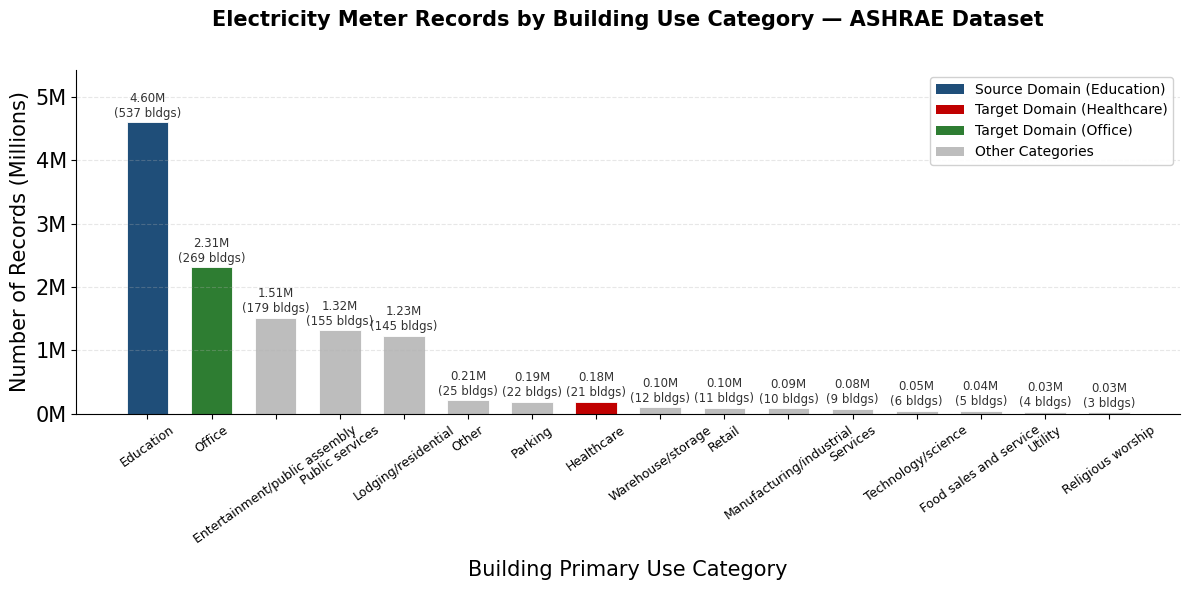

Saved to eda_domain_imbalance.png


In [5]:
# Cell 5: Domain Imbalance Bar Chart
#
# Shows the row/building count per building-use category, to
# visually confirm the scale of data imbalance between the source
# domain (Education) and the two target domains (Healthcare, Office).

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.patches import Patch

# ── Merge train with building_meta to get primary_use
merged = train.merge(building_meta, on='building_id', how='left')

# ── Filter electricity meter only (meter == 0)
elec = merged[merged['meter'] == 0].copy()

# ── Count rows and unique buildings per primary_use
domain_df = (
    elec.groupby('primary_use')
    .agg(
        Rows      = ('meter_reading', 'count'),
        Buildings = ('building_id',   'nunique')
    )
    .sort_values('Rows', ascending=False)
    .reset_index()
)

print(domain_df.to_string(index=False))

# ── Colour scheme:
#    Dark blue  = Source domain (Education)
#    Dark red   = Target domain (Healthcare)
#    Dark green = Target domain (Office)
#    Light grey = All other categories (not used in this study)
colors = []
for use in domain_df['primary_use']:
    if use == 'Education':
        colors.append('#1f4e79')
    elif use == 'Healthcare':
        colors.append('#c00000')
    elif use == 'Office':
        colors.append('#2e7d32')
    else:
        colors.append('#bdbdbd')

# ── Plot
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    domain_df['primary_use'],
    domain_df['Rows'] / 1e6,
    color     = colors,
    edgecolor = 'white',
    linewidth = 0.6,
    width     = 0.65
)

# ── Annotate each bar with row count and building count
for bar, rows, buildings in zip(bars,
                                 domain_df['Rows'],
                                 domain_df['Buildings']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.04,
        f'{rows/1e6:.2f}M\n({buildings} bldgs)',
        ha       = 'center',
        va       = 'bottom',
        fontsize = 8.5,
        color    = '#333333'
    )

# ── Axis labels and title
ax.set_xlabel('Building Primary Use Category', fontsize=15, labelpad=10)
ax.set_ylabel('Number of Records (Millions)',  fontsize=15)
ax.set_title(
    'Electricity Meter Records by Building Use Category — ASHRAE Dataset\n',
    fontsize   = 15,
    fontweight = 'bold',
    pad        = 15
)

# ── Y-axis formatter
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}M')
)
ax.set_ylim(0, domain_df['Rows'].max() / 1e6 * 1.18)

# ── Tick formatting
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', labelsize=15)

# ── Grid and spines
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Legend
legend_elements = [
    Patch(facecolor='#1f4e79', label='Source Domain (Education)'),
    Patch(facecolor='#c00000', label='Target Domain (Healthcare)'),
    Patch(facecolor='#2e7d32', label='Target Domain (Office)'),
    Patch(facecolor='#bdbdbd', label='Other Categories'),
]
ax.legend(handles=legend_elements, fontsize=10,
          loc='upper right', framealpha=0.9)

plt.tight_layout()

# ── Save (path matches visuals/ folder in the repo structure)
plt.savefig('eda_domain_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to eda_domain_imbalance.png")

Missing value percentages:
floor_count           82.652772
year_built            59.990033
cloud_coverage        43.655131
precip_depth_1_hr     18.544739
wind_direction         7.167792
sea_level_pressure     6.092515
wind_speed             0.710701
dew_temperature        0.495348
air_temperature        0.478124


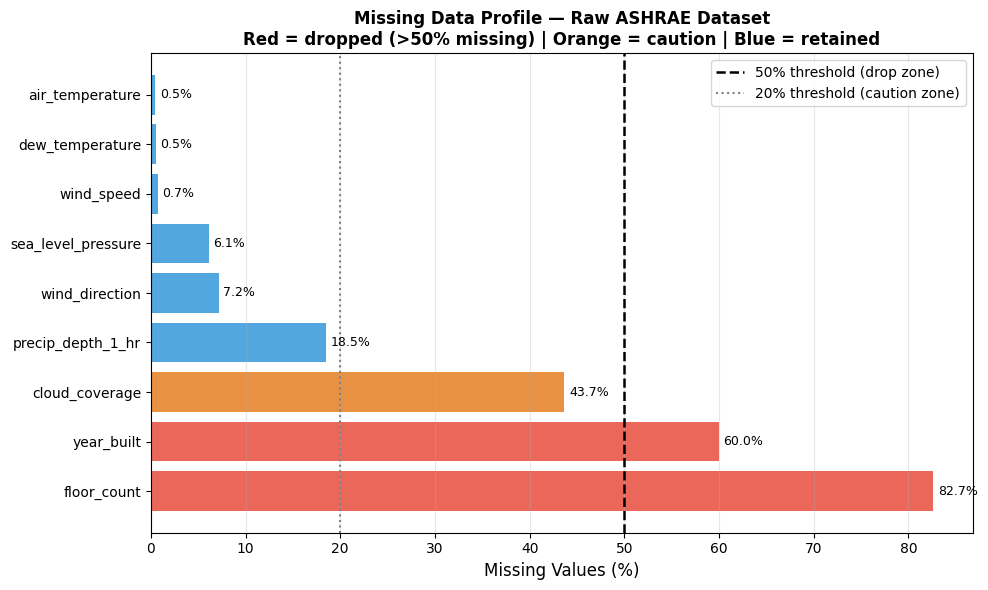

Saved to eda_missing_data.png


In [6]:
# Cell 6: EDA A — Missing Data Profile
#
# Shows what percentage of values are missing in each column, using
# a 50% threshold as the default cutoff for dropping a column
# entirely (see Cell 11: Imputation).

missing_pct = (
    eda_df.isnull().sum() / len(eda_df) * 100
).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print("Missing value percentages:")
print(missing_pct.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v >= 50 else '#e67e22' if v >= 20 else '#3498db'
          for v in missing_pct.values]
bars = ax.barh(missing_pct.index, missing_pct.values,
               color=colors, alpha=0.85)

ax.axvline(50, color='black', linestyle='--',
           linewidth=1.8, label='50% threshold (drop zone)')
ax.axvline(20, color='gray', linestyle=':',
           linewidth=1.5, label='20% threshold (caution zone)')

ax.set_xlabel('Missing Values (%)', fontsize=12)
ax.set_title(
    'Missing Data Profile — Raw ASHRAE Dataset\n'
    'Red = dropped (>50% missing) | Orange = caution | Blue = retained',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(True, axis='x', alpha=0.3)

for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_missing_data.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to eda_missing_data.png")

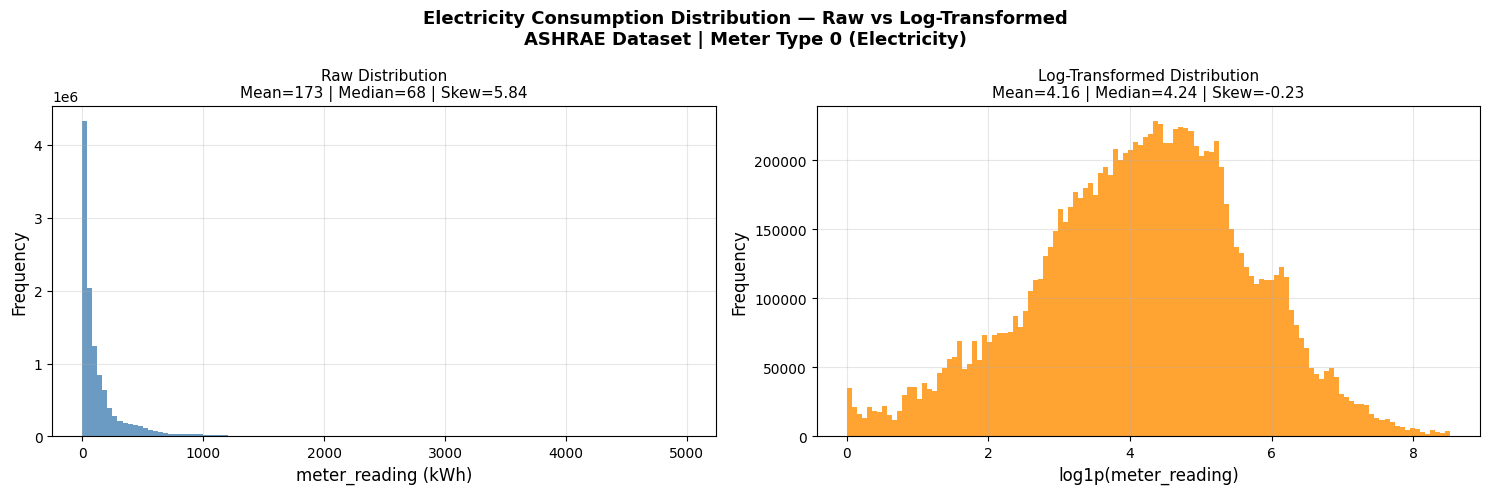

Saved to eda_distribution.png


In [7]:
# Cell 7: EDA B — Distribution Histograms (Raw vs Log1p)
#
# Electricity readings are heavily right-skewed (left panel).
# Log1p transformation compresses this skew (right panel), which is
# why the target variable is log-transformed before model training
# (see Cell 18 in 02_Baseline_Model.ipynb) — this prevents the loss
# function from being dominated by errors on a small number of very
# large buildings.

# Electricity only, remove zeros and top 0.1% for clean visualisation
elec_raw = eda_df[eda_df['meter'] == 0]['meter_reading']
elec_clean = elec_raw[
    (elec_raw > 0) & (elec_raw <= elec_raw.quantile(0.999))
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    'Electricity Consumption Distribution — Raw vs Log-Transformed\n'
    'ASHRAE Dataset | Meter Type 0 (Electricity)',
    fontsize=13, fontweight='bold'
)

# ── Raw distribution
axes[0].hist(elec_clean, bins=120, color='steelblue',
             alpha=0.8, edgecolor='none')
axes[0].set_xlabel('meter_reading (kWh)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(
    'Raw Distribution\n'
    f'Mean={elec_clean.mean():.0f} | Median={elec_clean.median():.0f} | '
    f'Skew={elec_clean.skew():.2f}',
    fontsize=11
)
axes[0].grid(True, alpha=0.3)

# ── Log-transformed distribution
log_vals = np.log1p(elec_clean)
axes[1].hist(log_vals, bins=120, color='darkorange',
             alpha=0.8, edgecolor='none')
axes[1].set_xlabel('log1p(meter_reading)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(
    'Log-Transformed Distribution\n'
    f'Mean={log_vals.mean():.2f} | Median={log_vals.median():.2f} | '
    f'Skew={log_vals.skew():.2f}',
    fontsize=11
)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to eda_distribution.png")

Education rows  : 4,597,256
Healthcare rows : 184,345
Office rows     : 2,310,203


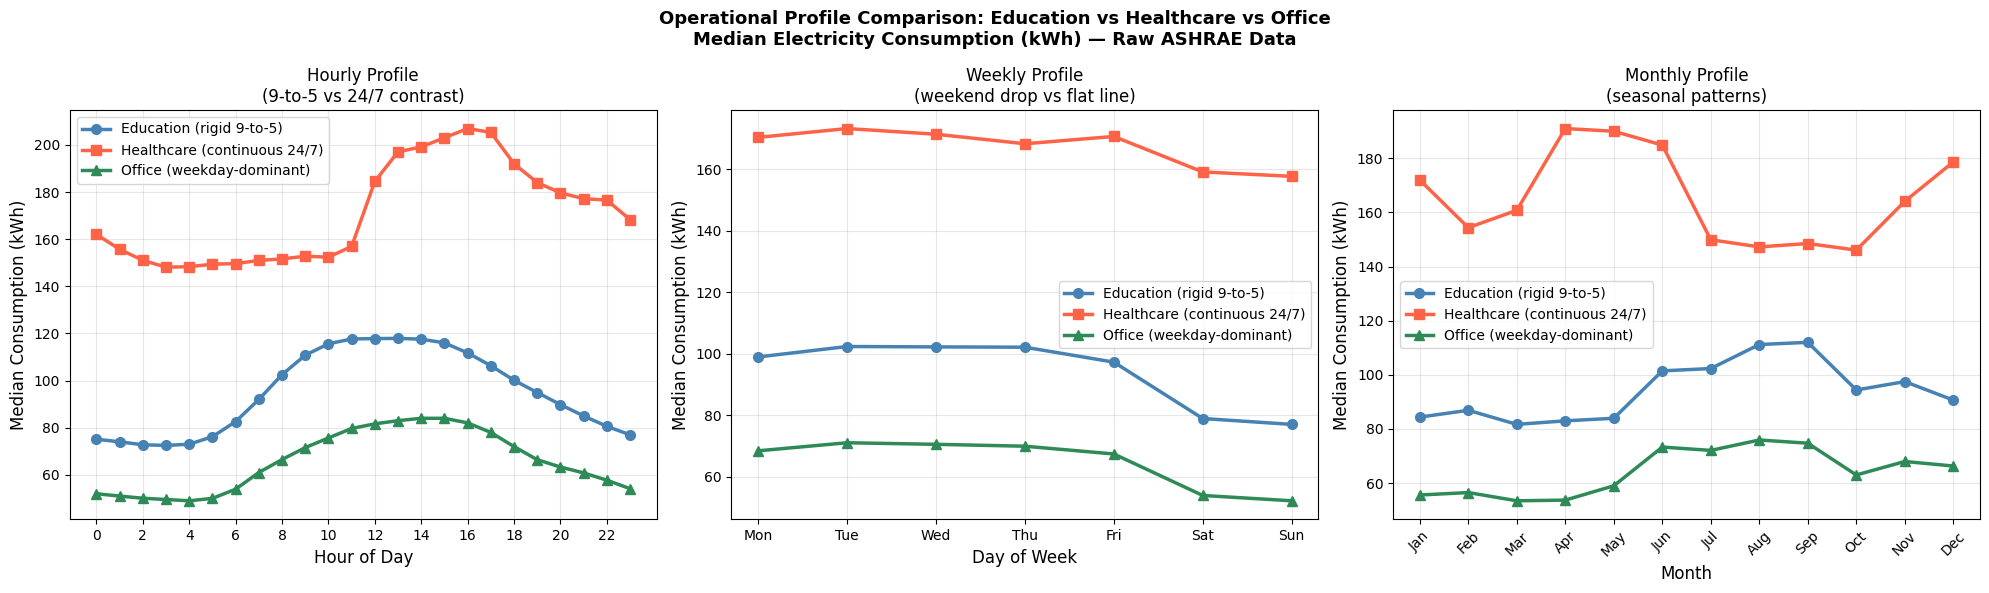


--- Hourly Median Consumption (kWh) ---
      Education  Healthcare    Office
hour                                 
0      75.11510    162.0030  52.00000
1      74.02500    155.6950  51.00000
2      72.76135    151.0005  50.08000
3      72.49250    148.1060  49.55000
4      73.00000    148.3240  49.00000
5      76.20000    149.3670  50.02500
6      82.59100    149.6335  53.92815
7      92.00000    150.9650  61.00000
8     102.51000    151.6265  66.50000
9     110.76000    152.7600  71.56075
10    115.60000    152.3600  75.66000
11    117.65000    156.9020  79.68420
12    117.81350    184.4910  81.64000
13    117.90000    197.0510  83.00000
14    117.57000    199.1220  84.00000
15    116.00000    203.0000  84.00000
16    111.75000    206.9255  82.05970
17    106.33000    205.3080  78.00000
18    100.12850    192.0000  72.00000
19     94.93665    184.0000  66.44300
20     89.82830    179.6650  63.33000
21     85.00000    177.1600  60.83000
22     80.60275    176.5780  57.75000
23     77

In [8]:
# Cell 8: EDA C — Domain Comparison (Hourly / Weekly / Monthly)
#
# Compares median electricity consumption across Education (source),
# Healthcare (dissimilar target), and Office (similar target), across
# three time granularities. This visually justifies the choice of
# Healthcare and Office as maximally-different vs. more-similar
# target domains relative to Education.

# Use eda_df (raw) — extract from electricity meter only
elec_eda = eda_df[eda_df['meter'] == 0].copy()

edu_eda    = elec_eda[elec_eda['primary_use'] == 'Education']
hc_eda     = elec_eda[elec_eda['primary_use'] == 'Healthcare']
office_eda = elec_eda[elec_eda['primary_use'] == 'Office']

print(f"Education rows  : {len(edu_eda):,}")
print(f"Healthcare rows : {len(hc_eda):,}")
print(f"Office rows     : {len(office_eda):,}")

# ── Hourly profiles
edu_hourly    = edu_eda.groupby('hour')['meter_reading'].median()
hc_hourly     = hc_eda.groupby('hour')['meter_reading'].median()
office_hourly = office_eda.groupby('hour')['meter_reading'].median()

# ── Weekly profiles
edu_daily    = edu_eda.groupby('day_of_week')['meter_reading'].median()
hc_daily     = hc_eda.groupby('day_of_week')['meter_reading'].median()
office_daily = office_eda.groupby('day_of_week')['meter_reading'].median()
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# ── Monthly profiles — showing seasonal patterns
edu_monthly    = edu_eda.groupby('month')['meter_reading'].median()
hc_monthly     = hc_eda.groupby('month')['meter_reading'].median()
office_monthly = office_eda.groupby('month')['meter_reading'].median()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'Operational Profile Comparison: Education vs Healthcare vs Office\n'
    'Median Electricity Consumption (kWh) — Raw ASHRAE Data',
    fontsize=13, fontweight='bold'
)

# ── Panel 1 — Hourly
axes[0].plot(edu_hourly.index, edu_hourly.values,
             'o-', color='steelblue', lw=2.5, ms=7,
             label='Education (rigid 9-to-5)')
axes[0].plot(hc_hourly.index, hc_hourly.values,
             's-', color='tomato', lw=2.5, ms=7,
             label='Healthcare (continuous 24/7)')
axes[0].plot(office_hourly.index, office_hourly.values,
             '^-', color='seagreen', lw=2.5, ms=7,
             label='Office (weekday-dominant)')
axes[0].set_xlabel('Hour of Day', fontsize=12)
axes[0].set_ylabel('Median Consumption (kWh)', fontsize=12)
axes[0].set_title('Hourly Profile\n(9-to-5 vs 24/7 contrast)', fontsize=12)
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Panel 2 — Weekly
axes[1].plot(range(7), edu_daily.values,
             'o-', color='steelblue', lw=2.5, ms=7,
             label='Education (rigid 9-to-5)')
axes[1].plot(range(7), hc_daily.values,
             's-', color='tomato', lw=2.5, ms=7,
             label='Healthcare (continuous 24/7)')
axes[1].plot(range(7), office_daily.values,
             '^-', color='seagreen', lw=2.5, ms=7,
             label='Office (weekday-dominant)')
axes[1].set_xlabel('Day of Week', fontsize=12)
axes[1].set_ylabel('Median Consumption (kWh)', fontsize=12)
axes[1].set_title('Weekly Profile\n(weekend drop vs flat line)', fontsize=12)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# ── Panel 3 — Monthly (seasonal)
axes[2].plot(range(1, 13), edu_monthly.values,
             'o-', color='steelblue', lw=2.5, ms=7,
             label='Education (rigid 9-to-5)')
axes[2].plot(range(1, 13), hc_monthly.values,
             's-', color='tomato', lw=2.5, ms=7,
             label='Healthcare (continuous 24/7)')
axes[2].plot(range(1, 13), office_monthly.values,
             '^-', color='seagreen', lw=2.5, ms=7,
             label='Office (weekday-dominant)')
axes[2].set_xlabel('Month', fontsize=12)
axes[2].set_ylabel('Median Consumption (kWh)', fontsize=12)
axes[2].set_title('Monthly Profile\n(seasonal patterns)', fontsize=12)
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(month_labels, rotation=45)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_domain_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print exact numbers for reference in the written dissertation
print("\n--- Hourly Median Consumption (kWh) ---")
comparison = pd.DataFrame({
    'Education' : edu_hourly,
    'Healthcare': hc_hourly,
    'Office'    : office_hourly
})
print(comparison.to_string())

print("\n--- Weekly Median Consumption (kWh) ---")
weekly_comparison = pd.DataFrame({
    'Day'       : day_labels,
    'Education' : edu_daily.values,
    'Healthcare': hc_daily.values,
    'Office'    : office_daily.values
})
print(weekly_comparison.to_string(index=False))
print("\nSaved to eda_domain_comparison.png")

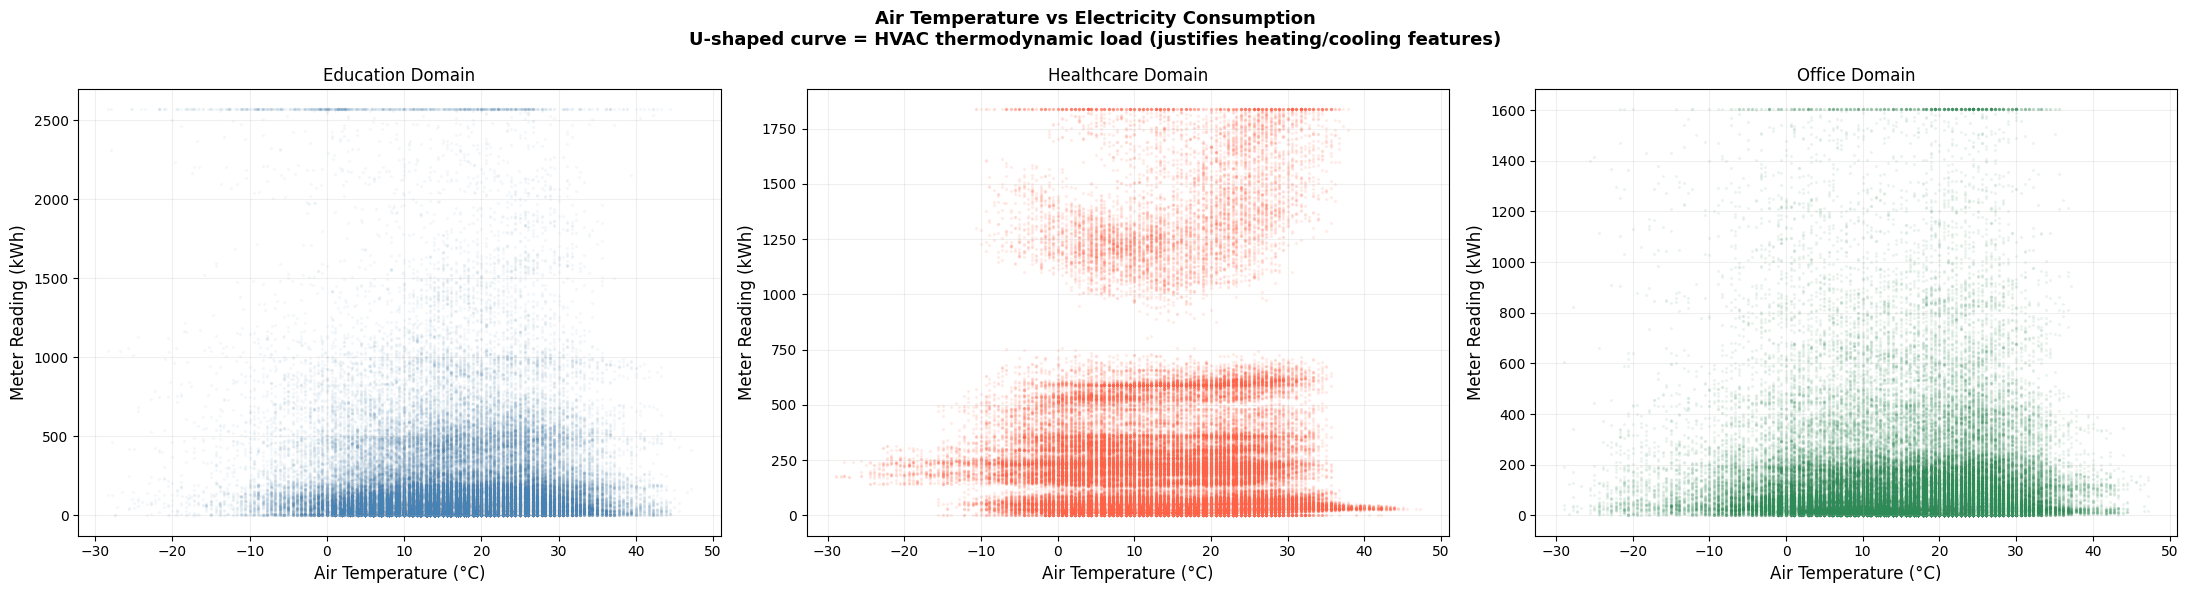

Saved to eda_temperature_consumption.png


In [9]:
# Cell 9: EDA D — Temperature vs Consumption Scatter
#
# Shows the relationship between outdoor air temperature and
# electricity consumption for each domain. The expected U-shaped
# curve (higher consumption at both temperature extremes) reflects
# HVAC thermodynamic load, and justifies engineering explicit
# heating_demand and cooling_demand features (see Cell 12).
#
# Note: depends on edu_eda, hc_eda, elec_eda from Cell 8 — run
# Cell 8 immediately before this one.

import matplotlib.pyplot as plt
import numpy as np

office_eda = elec_eda[elec_eda['primary_use'] == 'Office']

edu_sample     = edu_eda.sample(min(80000, len(edu_eda)), random_state=42)
hc_sample      = hc_eda.sample(min(80000, len(hc_eda)),  random_state=42)
office_sample  = office_eda.sample(min(80000, len(office_eda)), random_state=42)

# ── Cap y-axis at 99th percentile for visual clarity
edu_cap    = edu_eda['meter_reading'].quantile(0.99)
hc_cap     = hc_eda['meter_reading'].quantile(0.99)
office_cap = office_eda['meter_reading'].quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle(
    'Air Temperature vs Electricity Consumption\n'
    'U-shaped curve = HVAC thermodynamic load (justifies heating/cooling features)',
    fontsize=13, fontweight='bold'
)

axes[0].scatter(
    edu_sample['air_temperature'],
    edu_sample['meter_reading'].clip(upper=edu_cap),
    alpha=0.04, s=2, color='steelblue', rasterized=True
)
axes[0].set_xlabel('Air Temperature (°C)', fontsize=12)
axes[0].set_ylabel('Meter Reading (kWh)', fontsize=12)
axes[0].set_title('Education Domain', fontsize=12)
axes[0].grid(True, alpha=0.2)

axes[1].scatter(
    hc_sample['air_temperature'],
    hc_sample['meter_reading'].clip(upper=hc_cap),
    alpha=0.08, s=2, color='tomato', rasterized=True
)
axes[1].set_xlabel('Air Temperature (°C)', fontsize=12)
axes[1].set_ylabel('Meter Reading (kWh)', fontsize=12)
axes[1].set_title('Healthcare Domain', fontsize=12)
axes[1].grid(True, alpha=0.2)

axes[2].scatter(
    office_sample['air_temperature'],
    office_sample['meter_reading'].clip(upper=office_cap),
    alpha=0.06, s=2, color='seagreen', rasterized=True
)
axes[2].set_xlabel('Air Temperature (°C)', fontsize=12)
axes[2].set_ylabel('Meter Reading (kWh)', fontsize=12)
axes[2].set_title('Office Domain', fontsize=12)
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('eda_temperature_consumption.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to eda_temperature_consumption.png")

# Main Pipeline - Phase 1 : Data Engneering

In [10]:
# Cell 10: Memory Optimisation + Load + Merge
#
# This begins the main processing pipeline (separate from the EDA
# section above). Loads the raw CSVs fresh, merges into one master
# dataframe, and downcasts numeric columns to the smallest safe
# dtype to fit the dataset comfortably in Colab's GPU memory.

import pandas as pd
import numpy as np
import gc
import warnings
warnings.filterwarnings('ignore')

def reduce_mem_usage(df):
    """
    Downcasts numeric columns to the smallest safe type.
    float16 is intentionally excluded — its limited precision
    corrupts XGBoost gradient calculations.
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Optimizing memory... Initial size: {start_mem:.2f} MB')

    for col in df.columns:
        col_type = df[col].dtype
        if col_type == object or 'datetime' in str(col_type):
            continue

        c_min, c_max = df[col].min(), df[col].max()

        if str(col_type)[:3] == 'int':
            if   c_min > np.iinfo(np.int8).min  and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.int64)
        else:
            if   c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Done. Final size: {end_mem:.2f} MB '
          f'({100*(start_mem - end_mem)/start_mem:.1f}% reduction)')
    return df


# ── Load
print("Loading CSVs...")
path = '/content/ashrae_data/'

train         = pd.read_csv(path + 'train.csv')
building_meta = pd.read_csv(path + 'building_metadata.csv')
weather_train = pd.read_csv(path + 'weather_train.csv')

# ── Merge
print("Merging into master_df...")
master_df = train.merge(building_meta, on='building_id', how='left')
master_df = master_df.merge(weather_train, on=['site_id', 'timestamp'], how='left')

del train, building_meta, weather_train
gc.collect()

master_df = reduce_mem_usage(master_df)
print("\nmaster_df ready.")
print(f"Shape: {master_df.shape}")
print(master_df.dtypes)

Loading CSVs...
Merging into master_df...
Optimizing memory... Initial size: 2467.79 MB
Done. Final size: 1233.89 MB (50.0% reduction)

master_df ready.
Shape: (20216100, 16)
building_id             int16
meter                    int8
timestamp              object
meter_reading         float32
site_id                  int8
primary_use            object
square_feet             int32
year_built            float32
floor_count           float32
air_temperature       float32
cloud_coverage        float32
dew_temperature       float32
precip_depth_1_hr     float32
sea_level_pressure    float32
wind_direction        float32
wind_speed            float32
dtype: object


In [11]:
# Cell 11: Missing Data Imputation
#
# Drops weather columns with >50% missingness (imputing these would
# add more noise than signal), then fills the remaining weather gaps
# using forward-only linear interpolation, grouped by site. Forward-
# only (not bidirectional) prevents temporal leakage — a bidirectional
# fill could use future readings to estimate a past gap.

import pandas as pd
import numpy as np

print("Starting Missing Data Imputation...")
print(f"\nMissing values before:\n{master_df.isnull().sum()[master_df.isnull().sum() > 0]}")

# ── Drop high-missingness columns
# These columns are missing 50-70% of values
cols_to_drop = [
    'cloud_coverage',       # ~50% missing
    'sea_level_pressure',   # ~50% missing
    'precip_depth_1_hr',    # ~70% missing
    'year_built',           # ~50% missing across buildings
    'floor_count'           # ~75% missing across buildings
]
master_df = master_df.drop(columns=cols_to_drop)
print(f"\nDropped sparse columns: {cols_to_drop}")

# ── Sort chronologically within each site before interpolation
master_df['timestamp'] = pd.to_datetime(master_df['timestamp'], errors='coerce')
master_df = master_df.sort_values(['site_id', 'timestamp']).reset_index(drop=True)

# ── Time-aware interpolation
# Forward-only linear interpolation: fills gaps using the last known
# value. Back-fill is applied only to leading NaNs (start of a series
# with no prior value to interpolate from).
weather_cols = ['air_temperature', 'dew_temperature', 'wind_speed', 'wind_direction']

print("\nInterpolating weather columns (forward-fill, time-aware)...")
for col in weather_cols:
    master_df[col] = (
        master_df.groupby('site_id')[col]
        .transform(lambda g: g.interpolate(method='linear', limit_direction='forward'))
    )
    # Back-fill only the leading edge — not the entire series
    master_df[col] = (
        master_df.groupby('site_id')[col]
        .transform(lambda g: g.bfill())
    )

# ── Validation
remaining = master_df.isnull().sum()
remaining = remaining[remaining > 0]
if remaining.empty:
    print("\nNo missing values remaining.")
else:
    print(f"\nRemaining missing values:\n{remaining}")

Starting Missing Data Imputation...

Missing values before:
year_built            12127645
floor_count           16709167
air_temperature          96658
cloud_coverage         8825365
dew_temperature         100140
precip_depth_1_hr      3749023
sea_level_pressure     1231669
wind_direction         1449048
wind_speed              143676
dtype: int64

Dropped sparse columns: ['cloud_coverage', 'sea_level_pressure', 'precip_depth_1_hr', 'year_built', 'floor_count']

Interpolating weather columns (forward-fill, time-aware)...

No missing values remaining.


In [12]:
# Cell 12: Feature Engineering
#
# Builds three groups of features:
#   1. Temporal — raw time integers + cyclical sine/cosine encodings
#   2. Thermodynamic — heating/cooling demand, apparent temperature,
#      dew point spread (encodes weather-driven HVAC load directly,
#      rather than expecting the model to infer it from raw temperature)
#   3. Building-scale — log-transformed square footage

import pandas as pd
import numpy as np

print("Starting Feature Engineering...")

# ── Raw time features
master_df['month']       = master_df['timestamp'].dt.month.astype(np.int8)
master_df['day_of_week'] = master_df['timestamp'].dt.dayofweek.astype(np.int8)
master_df['hour']        = master_df['timestamp'].dt.hour.astype(np.int8)
master_df['is_weekend']  = (master_df['day_of_week'] >= 5).astype(np.int8)

# ── Cyclical encoding
# Maps cyclical time values onto a circle, so adjacent values
# (e.g. 23:00 and 00:00) stay numerically close — a raw integer
# encoding cannot express this.
master_df['hour_sin']  = np.sin(2 * np.pi * master_df['hour']        / 24).astype(np.float32)
master_df['hour_cos']  = np.cos(2 * np.pi * master_df['hour']        / 24).astype(np.float32)
master_df['month_sin'] = np.sin(2 * np.pi * master_df['month']       / 12).astype(np.float32)
master_df['month_cos'] = np.cos(2 * np.pi * master_df['month']       / 12).astype(np.float32)
master_df['dow_sin']   = np.sin(2 * np.pi * master_df['day_of_week'] / 7 ).astype(np.float32)
master_df['dow_cos']   = np.cos(2 * np.pi * master_df['day_of_week'] / 7 ).astype(np.float32)

# ── Thermodynamic features
# Base temperatures (18°C heating / 22°C cooling) reflect standard
# degree-day balance-point conventions in the building energy
# literature — see dissertation Section 3.3.3 for full justification.

# Heating Degree: how hard the heating system must work
master_df['heating_demand'] = np.maximum(
    0, 18 - master_df['air_temperature']
).astype(np.float32)

# Cooling Degree: how hard the cooling/AC system must work
master_df['cooling_demand'] = np.maximum(
    0, master_df['air_temperature'] - 22
).astype(np.float32)

# Apparent temperature (feels like) — affects HVAC load more than raw temp
master_df['apparent_temp'] = (
    master_df['air_temperature']
    - 0.4 * (master_df['air_temperature'] - 10)
    * (1 - master_df['wind_speed'] / 100)
).astype(np.float32)

# Dew point spread — proxy for atmospheric humidity load on cooling systems
master_df['temp_dew_spread'] = (
    master_df['air_temperature'] - master_df['dew_temperature']
).astype(np.float32)

# ── Building size (log-transformed)
# Raw square footage is heavily right-skewed (a few huge buildings
# dominate). Log-transform compresses the range and stabilises the
# relationship for tree-based splitting.
if 'square_feet' in master_df.columns:
    master_df['log_square_feet'] = np.log1p(
        master_df['square_feet']
    ).astype(np.float32)
    print("Created log_square_feet.")

print("\n--- Feature Engineering Complete ---")
print(f"Total columns: {master_df.shape[1]}")
print(master_df[['timestamp', 'hour', 'hour_sin', 'hour_cos',
                  'heating_demand', 'cooling_demand']].head(3))

Starting Feature Engineering...
Created log_square_feet.

--- Feature Engineering Complete ---
Total columns: 26
   timestamp  hour  hour_sin  hour_cos  heating_demand  cooling_demand
0 2016-01-01     0       0.0       1.0             0.0             3.0
1 2016-01-01     0       0.0       1.0             0.0             3.0
2 2016-01-01     0       0.0       1.0             0.0             3.0


In [13]:
# Cell 13: Electricity Filter + Domain Split + Outliers
#
# Isolates electricity-meter readings (meter == 0) and splits into
# the source domain (Education) and one target domain (Healthcare —
# Office is split out separately in 03_Transfer_Learning.ipynb, using
# electricity_df saved at the end of this notebook). Removes zero/
# negative readings (faulty meters) and the top 0.1% of readings
# (measurement anomalies). Excludes building_id/site_id from the
# feature set so the model cannot memorise specific buildings —
# it must learn transferable weather/time relationships instead.

import pandas as pd
import numpy as np

print("Isolating Electricity and Splitting Domains...")

# ── Electricity only (meter == 0)
electricity_df = master_df[master_df['meter'] == 0].copy()

# ── Source: Education | Target: Healthcare
source_df = electricity_df[electricity_df['primary_use'] == 'Education'].copy()
target_df = electricity_df[electricity_df['primary_use'] == 'Healthcare'].copy()

print(f"Before cleaning — Source: {source_df.shape[0]:,} rows | "
      f"Target: {target_df.shape[0]:,} rows")

# ── Outlier removal
# Zero/negative readings indicate a meter that was offline or faulty.
# Top 0.1% spikes are measurement anomalies.
def remove_outliers(df, label):
    q_upper = df['meter_reading'].quantile(0.999)
    mask    = (df['meter_reading'] > 0) & (df['meter_reading'] <= q_upper)
    n_out   = (~mask).sum()
    print(f"  {label}: removed {n_out:,} outlier rows "
          f"({n_out / len(df) * 100:.2f}%)")
    return df[mask].copy()

print("\nCleaning outliers...")
source_df = remove_outliers(source_df, 'Education')
target_df = remove_outliers(target_df, 'Healthcare')

print(f"\nAfter cleaning — Source: {source_df.shape[0]:,} rows | "
      f"Target: {target_df.shape[0]:,} rows")

# ── Feature columns
# Identifiers are excluded to prevent the model from memorising
# building-specific baselines instead of learning transferable
# weather/time relationships.
cols_to_drop = [
    'meter_reading', 'meter',
    'building_id', 'site_id', 'primary_use',
    'timestamp',
    'square_feet'        # replaced by log_square_feet
]
cols_to_drop = [c for c in cols_to_drop if c in source_df.columns]

# ── Log-transform the target variable
y_source = np.log1p(source_df['meter_reading'])
X_source = source_df.drop(columns=cols_to_drop)

y_target = np.log1p(target_df['meter_reading'])
X_target = target_df.drop(columns=cols_to_drop)

print(f"\nFeature set ({len(X_source.columns)} features):")
print(X_source.columns.tolist())
print("\nTarget variable: log1p(meter_reading) — convert back with np.expm1()")

Isolating Electricity and Splitting Domains...
Before cleaning — Source: 4,597,256 rows | Target: 184,345 rows

Cleaning outliers...
  Education: removed 184,989 outlier rows (4.02%)
  Healthcare: removed 6,241 outlier rows (3.39%)

After cleaning — Source: 4,412,267 rows | Target: 178,104 rows

Feature set (19 features):
['air_temperature', 'dew_temperature', 'wind_direction', 'wind_speed', 'month', 'day_of_week', 'hour', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'heating_demand', 'cooling_demand', 'apparent_temp', 'temp_dew_spread', 'log_square_feet']

Target variable: log1p(meter_reading) — convert back with np.expm1()


In [14]:
# Save Processed Data — End of 01_Data_Engineering.ipynb
#
# Saves the cleaned, feature-engineered dataframes needed by the next
# two notebooks. Saved directly to Drive (not /content/), since each
# notebook may run in a separate Colab session where /content/ is wiped.
#
# Used by:
#   - electricity_df.parquet → 03_Transfer_Learning.ipynb (Office split)
#   - source_df.parquet      → 02_Baseline_Model.ipynb (Base Model training)
#   - target_df.parquet      → 03_Transfer_Learning.ipynb (Healthcare)
#
# Parquet is used instead of CSV to preserve the exact downcasted
# dtypes from Cell 10 — saving to CSV would lose that memory
# optimisation entirely.

import os

processed_dir = '/content/drive/MyDrive/ashrae_outputs/processed_data/'
os.makedirs(processed_dir, exist_ok=True)

electricity_df.to_parquet(processed_dir + 'electricity_df.parquet', index=False)
source_df.to_parquet(processed_dir + 'source_df.parquet', index=False)
target_df.to_parquet(processed_dir + 'target_df.parquet', index=False)

print(f"Saved to {processed_dir}:")
print(f"  electricity_df.parquet ({electricity_df.shape})")
print(f"  source_df.parquet      ({source_df.shape})")
print(f"  target_df.parquet      ({target_df.shape})")

Saved to /content/drive/MyDrive/ashrae_outputs/processed_data/:
  electricity_df.parquet ((12060910, 26))
  source_df.parquet      ((4412267, 26))
  target_df.parquet      ((178104, 26))


In [15]:
# Backup EDA Plots — Add to the end of 01_Data_Engineering.ipynb,
# right after the existing "Save Processed Data" cell.
#
# The dataframes are already saved to processed_data/ — this step
# saves the five EDA plots (currently only in /content/) to Drive too.

import shutil
import os

visuals_dir = '/content/drive/MyDrive/ashrae_outputs/visuals/'
os.makedirs(visuals_dir, exist_ok=True)

eda_plots = [
    'eda_domain_imbalance.png',
    'eda_missing_data.png',
    'eda_distribution.png',
    'eda_domain_comparison.png',
    'eda_temperature_consumption.png',
]

for filename in eda_plots:
    src = f'/content/{filename}'
    dst = visuals_dir + filename
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"✓ {filename} → {visuals_dir}")
    else:
        print(f"✗ {filename} NOT FOUND — check the EDA cell ran successfully.")

✓ eda_domain_imbalance.png → /content/drive/MyDrive/ashrae_outputs/visuals/
✓ eda_missing_data.png → /content/drive/MyDrive/ashrae_outputs/visuals/
✓ eda_distribution.png → /content/drive/MyDrive/ashrae_outputs/visuals/
✓ eda_domain_comparison.png → /content/drive/MyDrive/ashrae_outputs/visuals/
✓ eda_temperature_consumption.png → /content/drive/MyDrive/ashrae_outputs/visuals/
